# SIFT — Data Exploration

**SIFT:** Statistical Intelligence for Text Filtering

## Objective

Understand the SMS Spam Collection dataset before performing
any cleaning, feature engineering, or model training.

### Questions

1. What is the size of the dataset?
2. What are the available fields?
3. Are there missing values?
4. Are there duplicate messages?
5. What is the class distribution?
6. How long are messages?
7. What patterns distinguish spam from ham?

In [1]:
import pandas as pd

In [2]:
data_path = "../data/raw/SMSSpamCollection"

df = pd.read_csv(
    data_path,
    sep="\t",
    header=None,
    names=["label", "message"]
)

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
sep="\t"

In [5]:
header=None

In [6]:
names=["label", "message"]

In [7]:
df.shape

(5572, 2)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [9]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
df["label"].value_counts(normalize=True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

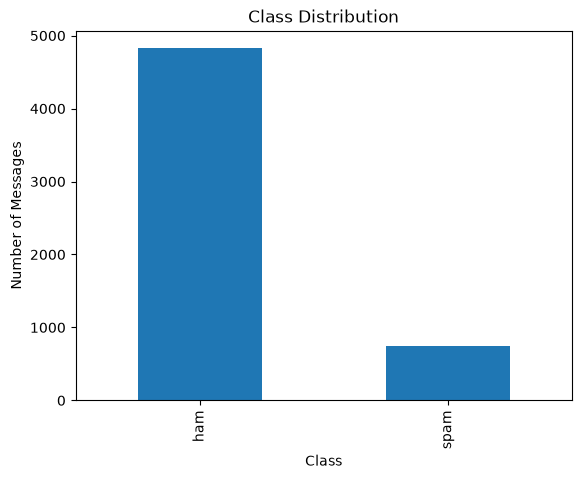

In [11]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()

In [12]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

In [14]:
df[df.duplicated()].head()

,label,message
103,ham,As per your request 'Melle Melle (Oru Minnamin...
154,ham,As per your request 'Melle Melle (Oru Minnamin...
207,ham,"As I entered my cabin my PA said, '' Happy B'd..."
223,ham,"Sorry, I'll call later"
326,ham,No calls..messages..missed calls


In [15]:
df = df.drop_duplicates()

## Initial Findings

- The dataset contains 5,574 SMS messages.
- There are two classes: `ham` and `spam`.
- The dataset is significantly imbalanced toward `ham`.
- Missing-value checks will be used to verify data completeness.
- Duplicate messages are present and require further investigation.

In [16]:
df["message_length"] = df["message"].str.len()

In [17]:
df["message_length"].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64

In [18]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


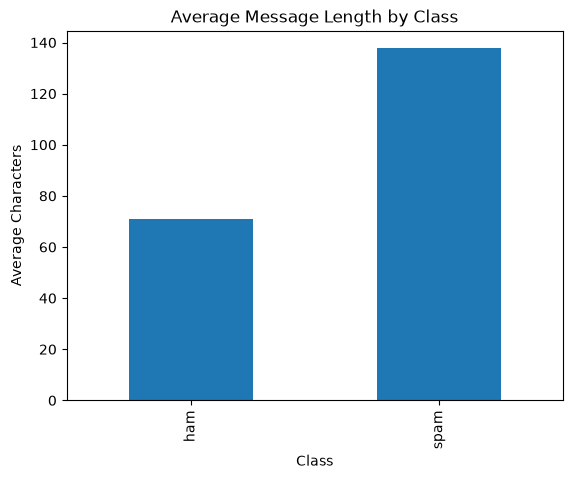

In [19]:
df.groupby("label")["message_length"].mean().plot(kind="bar")

plt.title("Average Message Length by Class")
plt.xlabel("Class")
plt.ylabel("Average Characters")
plt.show()

In [20]:
df[df["label"] == "spam"]["message"].head(20).tolist()

["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
 "FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv",
 'WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.',
 'Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030',
 'SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info',
 'URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18',
 'XXXMobileMovieClub: To use your credit, click the WAP link in th

In [21]:
df[df["label"] == "ham"]["message"].head(20).tolist()

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
 'Ok lar... Joking wif u oni...',
 'U dun say so early hor... U c already then say...',
 "Nah I don't think he goes to usf, he lives around here though",
 'Even my brother is not like to speak with me. They treat me like aids patent.',
 "As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune",
 "I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.",
 "I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.",
 'I HAVE A DATE ON SUNDAY WITH WILL!!',
 "Oh k...i'm watching here:)",
 'Eh u remember how 2 spell his name... Yes i did. He v naughty make until i v wet.',
 'Fine if t

In [22]:
import os

print(os.getcwd())

d:\python\machine-learning-projects\SIFT\notebooks


In [23]:
import os
import sys

print("Current working directory:")
print(os.getcwd())

print("\nPython executable:")
print(sys.executable)

print("\nPython search paths:")
for path in sys.path:
    print(path)

Current working directory:
d:\python\machine-learning-projects\SIFT\notebooks

Python executable:
d:\python\machine-learning-projects\SIFT\.venv\Scripts\python.exe

Python search paths:
C:\Users\jaysw\AppData\Local\Programs\Python\Python311\python311.zip
C:\Users\jaysw\AppData\Local\Programs\Python\Python311\DLLs
C:\Users\jaysw\AppData\Local\Programs\Python\Python311\Lib
C:\Users\jaysw\AppData\Local\Programs\Python\Python311
d:\python\machine-learning-projects\SIFT\.venv

d:\python\machine-learning-projects\SIFT\.venv\Lib\site-packages


In [24]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\python\machine-learning-projects\SIFT


In [25]:
from src.data.preprocessing import clean_text

In [26]:
sample = "  FREE    MONEY!!! \n CLICK NOW!!!  "

clean_text(sample)

'free money!!! click now!!!'

In [27]:
# Create a working copy for preprocessing experiments
df_clean = df.copy()

# Apply our current text-cleaning function
df_clean["clean_message"] = df_clean["message"].apply(clean_text)

df_clean.head()

,label,message,message_length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,"go until jurong point, crazy.. available only ..."
1,ham,Ok lar... Joking wif u oni...,29,ok lar... joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,u dun say so early hor... u c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,"nah i don't think he goes to usf, he lives aro..."


## Experiment A — Punctuation

In [28]:
import string

def count_punctuation(text):
    return sum(char in string.punctuation for char in text)

df_clean["punctuation_count"] = df_clean["message"].apply(count_punctuation)

df_clean.groupby("label")["punctuation_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,3.830159,4.488122,0.0,1.0,3.0,5.0,133.0
spam,653.0,5.643185,3.500627,0.0,3.0,5.0,8.0,26.0


In [29]:
df_clean.groupby("label")["punctuation_count"].mean()

label
ham     3.830159
spam    5.643185
Name: punctuation_count, dtype: float64

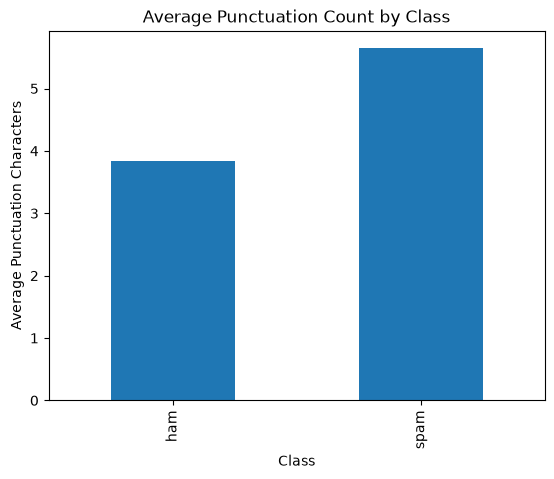

In [30]:
df_clean.groupby("label")["punctuation_count"].mean().plot(kind="bar")

plt.title("Average Punctuation Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Punctuation Characters")
plt.show()

## Experiment B — Numbers

In [31]:
def count_digits(text):
    return sum(char.isdigit() for char in text)

df_clean["digit_count"] = df_clean["message"].apply(count_digits)

In [32]:
df_clean.groupby("label")["digit_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,0.296723,1.023359,0.0,0.0,0.0,0.0,23.0
spam,653.0,15.488515,8.895712,0.0,10.0,16.0,22.0,47.0


In [33]:
df_clean.groupby("label")["digit_count"].mean()

label
ham      0.296723
spam    15.488515
Name: digit_count, dtype: float64

In [34]:
df_clean[
    (df_clean["label"] == "spam") &
    (df_clean["digit_count"] > 0)
][["message", "digit_count"]].head(15)

,message,digit_count
2,Free entry in 2 a wkly comp to win FA Cup fina...,25
5,FreeMsg Hey there darling it's been 3 week's n...,4
8,WINNER!! As a valued network customer you have...,19
9,Had your mobile 11 months or more? U R entitle...,13
11,"SIX chances to win CASH! From 100 to 20,000 po...",22
12,URGENT! You have won a 1 week FREE membership ...,20
19,England v Macedonia - dont miss the goals/team...,23
34,Thanks for your subscription to Ringtone UK yo...,1
42,07732584351 - Rodger Burns - MSG = We tried to...,22
56,Congrats! 1 year special cinema pass for 2 is ...,24


## Experiment C — URLs

In [35]:
url_pattern = r"http|www|\.com|\.net|\.org"

url_mask = df_clean["message"].str.contains(
    url_pattern,
    case=False,
    regex=True,
    na=False
)

In [36]:
url_mask.sum()

np.int64(122)

In [37]:
df_clean[url_mask]["label"].value_counts()

label
spam    108
ham      14
Name: count, dtype: int64

In [38]:
df_clean[url_mask][["label", "message"]].head(15)

,label,message
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
136,ham,I only haf msn. It's yijue@hotmail.com
164,spam,-PLS STOP bootydelious (32/F) is inviting you ...
191,spam,Are you unique enough? Find out from 30th Augu...
225,spam,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA..."
250,spam,Congratulations ur awarded 500 of CD vouchers ...
268,spam,Ur ringtone service has changed! 25 Free credi...
273,spam,HMV BONUS SPECIAL 500 pounds of genuine HMV vo...
305,spam,SMS. ac Blind Date 4U!: Rodds1 is 21/m from Ab...


In [39]:
duplicate_mask = df_clean.duplicated(
    subset=["message"],
    keep=False
)

df_clean[duplicate_mask][["label", "message"]].head(20)

,label,message


In [40]:
label_conflicts = (
    df_clean.groupby("message")["label"]
    .nunique()
)

In [41]:
label_conflicts.value_counts()

label
1    5169
Name: count, dtype: int64

In [42]:
df_clean["message"].duplicated().sum()

np.int64(0)

In [43]:
df_clean["message"].nunique()

5169

## Duplicate Analysis

The dataset contains:

- Total messages: 5167
- Unique messages: 5167
- Duplicate occurrences: 0
- Conflicting labels among identical messages: 1

Duplicate messages will be handled before model evaluation to reduce
the possibility of train/test contamination.

In [44]:
print("===== SIFT DATA QUALITY SUMMARY =====")

# 1. Average punctuation
avg_punctuation = df_clean.groupby("label")["punctuation_count"].mean()

print("\n1. Average punctuation:")
print(f"Ham  : {avg_punctuation['ham']:.2f}")
print(f"Spam : {avg_punctuation['spam']:.2f}")


# 2. Average digits
avg_digits = df_clean.groupby("label")["digit_count"].mean()

print("\n2. Average digits:")
print(f"Ham  : {avg_digits['ham']:.2f}")
print(f"Spam : {avg_digits['spam']:.2f}")


# 3. URL-containing messages
url_counts = df_clean[url_mask]["label"].value_counts()

print("\n3. Messages containing URLs:")
print(f"Ham  : {url_counts.get('ham', 0)}")
print(f"Spam : {url_counts.get('spam', 0)}")


# 4. Total duplicate occurrences
duplicate_count = df_clean["message"].duplicated().sum()

print("\n4. Total duplicate occurrences:")
print(duplicate_count)


# 5. Unique messages
unique_count = df_clean["message"].nunique()

print("\n5. Unique messages:")
print(unique_count)


# 6. Conflicting labels
conflicting_messages = (label_conflicts > 1).sum()

print("\n6. Messages with conflicting labels:")
print(conflicting_messages)


===== SIFT DATA QUALITY SUMMARY =====

1. Average punctuation:
Ham  : 3.83
Spam : 5.64

2. Average digits:
Ham  : 0.30
Spam : 15.49

3. Messages containing URLs:
Ham  : 14
Spam : 108

4. Total duplicate occurrences:
0

5. Unique messages:
5169

6. Messages with conflicting labels:
0


In [45]:
print("Rows in original df      :", len(df))
print("Rows in df_clean         :", len(df_clean))
print("Unique messages in df    :", df["message"].nunique())
print("Unique messages in clean :", df_clean["message"].nunique())
print("Duplicate rows in df     :", df["message"].duplicated().sum())
print("Duplicate rows in clean  :", df_clean["message"].duplicated().sum())

Rows in original df      : 5169
Rows in df_clean         : 5169
Unique messages in df    : 5169
Unique messages in clean : 5169
Duplicate rows in df     : 0
Duplicate rows in clean  : 0


## Feature Engineering

In [46]:
from src.features.tfidf import tokenize

sample_text = "FREE money! Call now."

tokens = tokenize(sample_text)

print(tokens)

['free', 'money', '!', 'call', 'now', '.']


In [47]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [48]:
from src.features.tfidf import tokenize, build_vocabulary

In [49]:
sample_documents = [
    "hello friend",
    "free prize",
    "hello prize"
]

vocab = build_vocabulary(sample_documents)

print(vocab)

{'hello': 0, 'friend': 1, 'free': 2, 'prize': 3}


## Train/Test Split

In [51]:
import numpy as np

# Make results reproducible
np.random.seed(42)

# Get indices for each class
ham_indices = df_clean.index[df_clean["label"] == "ham"].to_numpy().copy()
spam_indices = df_clean.index[df_clean["label"] == "spam"].to_numpy().copy()

# Shuffle each class separately
np.random.shuffle(ham_indices)
np.random.shuffle(spam_indices)

# 80% for training
ham_split = int(0.8 * len(ham_indices))
spam_split = int(0.8 * len(spam_indices))

ham_train = ham_indices[:ham_split]
ham_test = ham_indices[ham_split:]

spam_train = spam_indices[:spam_split]
spam_test = spam_indices[spam_split:]

# Combine classes
train_indices = np.concatenate([ham_train, spam_train])
test_indices = np.concatenate([ham_test, spam_test])

# Shuffle final train/test indices
np.random.shuffle(train_indices)
np.random.shuffle(test_indices)

# Create train and test DataFrames
train_df = df_clean.loc[train_indices].copy()
test_df = df_clean.loc[test_indices].copy()

print("Training samples:", len(train_df))
print("Testing samples :", len(test_df))

Training samples: 4134
Testing samples : 1035


In [52]:
print("Training distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTesting distribution:")
print(test_df["label"].value_counts(normalize=True))

Training distribution:
label
ham     0.87373
spam    0.12627
Name: proportion, dtype: float64

Testing distribution:
label
ham     0.87343
spam    0.12657
Name: proportion, dtype: float64


In [53]:
y_train = train_df["label"].map({
    "ham": 0,
    "spam": 1
}).to_numpy()

y_test = test_df["label"].map({
    "ham": 0,
    "spam": 1
}).to_numpy()

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

y_train shape: (4134,)
y_test shape : (1035,)


In [54]:
X_train_text = train_df["clean_message"].tolist()
X_test_text = test_df["clean_message"].tolist()

vocabulary = build_vocabulary(X_train_text)

print("Number of training documents:", len(X_train_text))
print("Vocabulary size:", len(vocabulary))

Number of training documents: 4134
Vocabulary size: 7758


In [55]:
print("First 30 vocabulary entries:")
print(list(vocabulary.items())[:30])

First 30 vocabulary entries:
[('sir', 0), (',', 1), ('hope', 2), ('your', 3), ('day', 4), ('is', 5), ('going', 6), ('smoothly', 7), ('.', 8), ('i', 9), ('really', 10), ('hoped', 11), ('wont', 12), ('have', 13), ('to', 14), ('bother', 15), ('you', 16), ('about', 17), ('this', 18), ('some', 19), ('bills', 20), ('that', 21), ('can', 22), ("'", 23), ('t', 24), ('settle', 25), ('month', 26), ('am', 27), ('out', 28), ('of', 29)]


In [56]:
print("Vocabulary size:", len(vocabulary))

Vocabulary size: 7758


In [61]:
import importlib
import src.features.tfidf as tfidf

importlib.reload(tfidf)

<module 'src.features.tfidf' from 'd:\\python\\machine-learning-projects\\SIFT\\src\\features\\tfidf.py'>

In [62]:
from src.features.tfidf import compute_tf

In [63]:
sample_tokens = [
    "free",
    "free",
    "prize",
    "now"
]

tf = compute_tf(sample_tokens)

print(tf)

{'free': 0.5, 'prize': 0.25, 'now': 0.25}


In [64]:
import importlib
import src.features.tfidf as tfidf

importlib.reload(tfidf)

<module 'src.features.tfidf' from 'd:\\python\\machine-learning-projects\\SIFT\\src\\features\\tfidf.py'>

In [65]:
from src.features.tfidf import (
    build_vocabulary,
    compute_document_frequency
)

In [66]:
sample_documents = [
    "free money now",
    "free prize",
    "hello friend"
]

sample_vocab = build_vocabulary(sample_documents)

df_test = compute_document_frequency(
    sample_documents,
    sample_vocab
)

print(df_test)

{'free': 2, 'money': 1, 'now': 1, 'prize': 1, 'hello': 1, 'friend': 1}


In [67]:
document_frequency = compute_document_frequency(
    X_train_text,
    vocabulary
)

print("Number of vocabulary terms:", len(vocabulary))
print("Number of DF entries:", len(document_frequency))

Number of vocabulary terms: 7758
Number of DF entries: 7758


In [68]:
print(list(document_frequency.items())[:20])

[('sir', 24), (',', 949), ('hope', 92), ('your', 424), ('day', 148), ('is', 551), ('going', 135), ('smoothly', 1), ('.', 2697), ('i', 1576), ('really', 65), ('hoped', 2), ('wont', 27), ('have', 397), ('to', 1248), ('bother', 7), ('you', 1217), ('about', 110), ('this', 246), ('some', 90)]


In [69]:
import importlib
import src.features.tfidf as tfidf

importlib.reload(tfidf)

<module 'src.features.tfidf' from 'd:\\python\\machine-learning-projects\\SIFT\\src\\features\\tfidf.py'>

In [70]:
from src.features.tfidf import compute_idf

In [71]:
sample_documents = [
    "free money now",
    "free prize",
    "hello friend"
]

sample_vocab = build_vocabulary(sample_documents)

sample_df = compute_document_frequency(
    sample_documents,
    sample_vocab
)

sample_idf = compute_idf(
    sample_df,
    len(sample_documents)
)

print(sample_idf)

{'free': 0.4054651081081644, 'money': 1.0986122886681098, 'now': 1.0986122886681098, 'prize': 1.0986122886681098, 'hello': 1.0986122886681098, 'friend': 1.0986122886681098}


In [72]:
idf = compute_idf(
    document_frequency,
    len(X_train_text)
)

print("Number of IDF values:", len(idf))

Number of IDF values: 7758


In [73]:
most_common_terms = sorted(
    document_frequency.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Most common terms:")
for token, df in most_common_terms[:20]:
    print(f"{token:15} {df}")

Most common terms:
.               2697
i               1576
to              1248
you             1217
'               1010
,               949
?               939
a               834
the             787
!               674
and             621
u               605
in              600
is              551
me              518
for             487
it              471
my              460
your            424
:               413


In [75]:
most_informative_terms = sorted(
    idf.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nHighest-IDF terms:")
for token, value in most_informative_terms[:20]:
    print(f"{token:15} {value:.4f}")


Highest-IDF terms:
smoothly        8.3270
bills           8.3270
challenging     8.3270
dolls           8.3270
patrick         8.3270
swayze          8.3270
hectic          8.3270
yalru           8.3270
lyfu            8.3270
astne           8.3270
innu            8.3270
mundhe          8.3270
lyf             8.3270
ali             8.3270
halla           8.3270
bilo            8.3270
edhae           8.3270
ovr             8.3270
vargu           8.3270
meow            8.3270


In [76]:
df_clean.groupby("label")["punctuation_count"].mean()

label
ham     3.830159
spam    5.643185
Name: punctuation_count, dtype: float64

In [78]:
importlib.reload(tfidf)

<module 'src.features.tfidf' from 'd:\\python\\machine-learning-projects\\SIFT\\src\\features\\tfidf.py'>

In [79]:
from src.features.tfidf import compute_tfidf_vector

In [80]:
sample_vector = compute_tfidf_vector(
    "free prize",
    sample_vocab,
    sample_idf
)

print(sample_vector)
print("Vector length:", len(sample_vector))

[0.2027325540540822, 0.0, 0.0, 0.5493061443340549, 0.0, 0.0]
Vector length: 6


In [82]:
importlib.reload(tfidf)

<module 'src.features.tfidf' from 'd:\\python\\machine-learning-projects\\SIFT\\src\\features\\tfidf.py'>

In [83]:
from src.features.tfidf import transform_documents

In [84]:
X_train_tfidf = transform_documents(
    X_train_text,
    vocabulary,
    idf
)

print("X_train shape:", X_train_tfidf.shape)

X_train shape: (4134, 7758)


In [85]:
X_test_tfidf = transform_documents(
    X_test_text,
    vocabulary,
    idf
)

print("X_test shape:", X_test_tfidf.shape)

X_test shape: (1035, 7758)


In [86]:
print("X_train:", X_train_tfidf.shape)
print("X_test :", X_test_tfidf.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4134, 7758)
X_test : (1035, 7758)
y_train: (4134,)
y_test : (1035,)


In [87]:
print("X_train shape:", X_train_tfidf.shape)
print("X_test shape :", X_test_tfidf.shape)

print("X_train dtype:", X_train_tfidf.dtype)
print("X_test dtype :", X_test_tfidf.dtype)

print(
    "Train NaN:",
    np.isnan(X_train_tfidf).sum()
)

print(
    "Train Inf:",
    np.isinf(X_train_tfidf).sum()
)

X_train shape: (4134, 7758)
X_test shape : (1035, 7758)
X_train dtype: float64
X_test dtype : float64
Train NaN: 0
Train Inf: 0
